In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#importing data
df = pd.read_csv("wine.csv")

In [ ]:
#spliting variables In X And Y
x = df.iloc[:, 1:]
Y = df['Type']


In [ ]:
# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
SS_X = scaler.fit_transform(x)

In [ ]:
# Train-test split for linear regression
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(SS_X, Y, test_size=0.30, random_state=0)

In [ ]:
# Linear Regression model fitting
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Predictions
Y_pred_train = LR.predict(X_train)
Y_pred_test = LR.predict(X_test)

In [ ]:
# Metrics for linear regression
from sklearn.metrics import mean_squared_error
error1 = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
print("Train Error:", error1.round(3))

error2 = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
print("Test Error:", error2.round(3))

Train Error: 0.226
Test Error: 0.301


In [ ]:
# Validation set approach for linear regression
training_errors = []
test_errors = []

for i in range(1, 1001):
    X_train, X_test, Y_train, Y_test = train_test_split(SS_X, Y, test_size=0.30, random_state=i)
    LR.fit(X_train, Y_train)
    Y_pred_train = LR.predict(X_train)
    Y_pred_test = LR.predict(X_test)
    training_errors.append(np.sqrt(mean_squared_error(Y_train, Y_pred_train)))
    test_errors.append(np.sqrt(mean_squared_error(Y_test, Y_pred_test)))

print("Average training error:", np.mean(training_errors).round(3))
print("Average test error:", np.mean(test_errors).round(3))


Average training error: 0.239
Average test error: 0.276


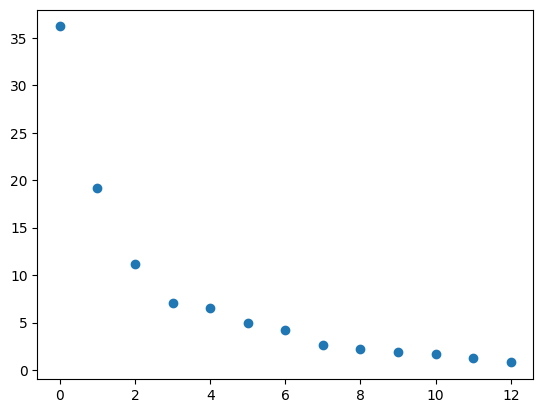

In [ ]:
#PCA
from sklearn.decomposition import PCA
pca = PCA()
pca_result = pca.fit_transform(SS_X)
pc_df=pd.DataFrame(pca_result)
pd.DataFrame((pca.explained_variance_ratio_)*100)
# Plot explained variance ratio to decide the number of components to keep
import matplotlib.pyplot as plt
plt.scatter(range(0,13),pd.DataFrame((pca.explained_variance_ratio_)*100))
plt.show()


In [ ]:

# Select the number of components for PCA
num_components = 3
pca_selected = PCA(n_components=num_components)
pca_scores = pca_selected.fit_transform(SS_X)

In [ ]:
# KMeans clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(pca_scores)
    inertia.append(kmeans.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

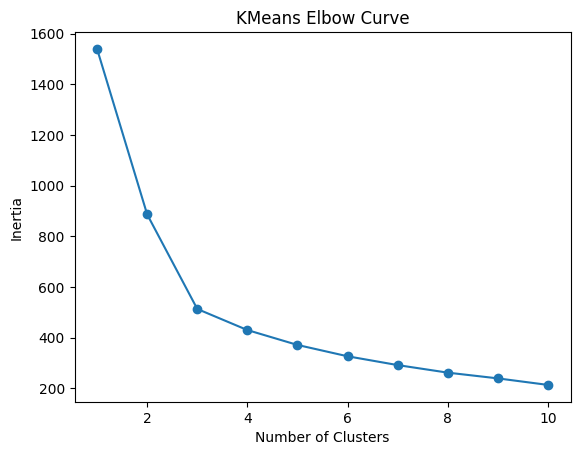

In [ ]:
# Plot the elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('KMeans Elbow Curve')
plt.show()

In [ ]:
# Choose the optimal number of clusters for KMeans based on the elbow curve
optimal_clusters_kmeans = 3

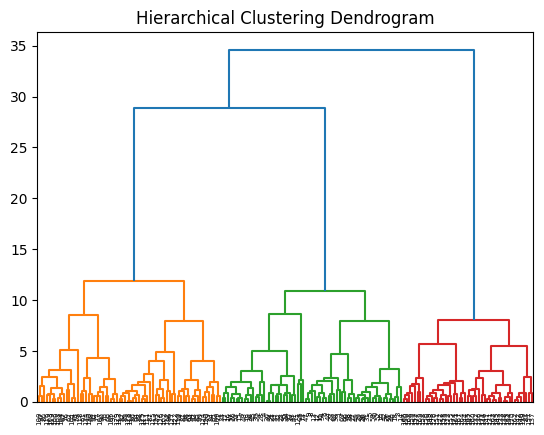

In [ ]:
# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(pca_scores, method='ward')
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

In [ ]:
# Choose the optimal number of clusters for hierarchical clustering based on the dendrogram
optimal_clusters_hierarchy = 3

In [ ]:
# Use KMeans and Hierarchical clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_clusters_kmeans, random_state=0)
kmeans_labels = kmeans.fit_predict(pca_scores)

hierarchical = AgglomerativeClustering(n_clusters=optimal_clusters_hierarchy).fit_predict(pca_scores)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
# Compare the obtained clusters with the original 'Type' column
df['Cluster_KMeans'] = kmeans.labels_
df['Cluster_Hierarchical'] = hierarchical

In [ ]:
print(df[['Type', 'Cluster_KMeans', 'Cluster_Hierarchical']])

     Type  Cluster_KMeans  Cluster_Hierarchical
0       1               2                     2
1       1               2                     2
2       1               2                     2
3       1               2                     2
4       1               2                     2
..    ...             ...                   ...
173     3               0                     1
174     3               0                     1
175     3               0                     1
176     3               0                     1
177     3               0                     1

[178 rows x 3 columns]


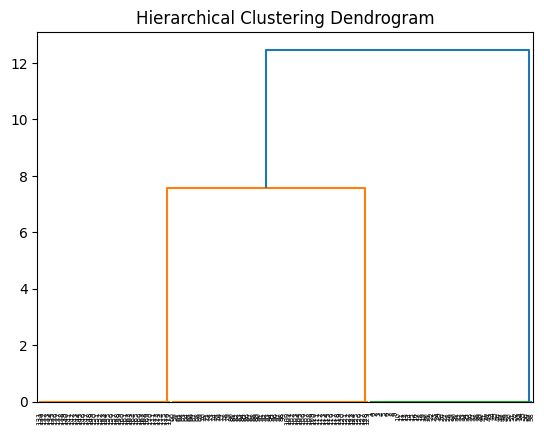

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(df[['Type']], method='ward')
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

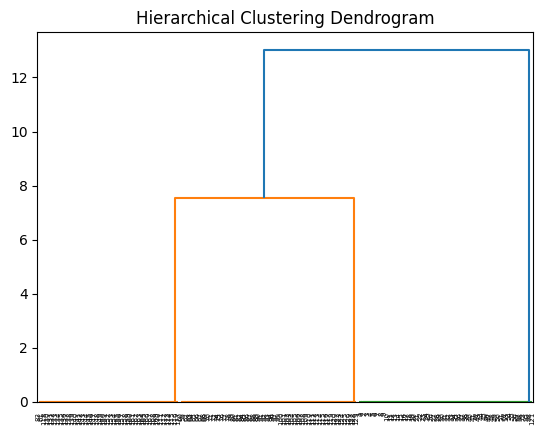

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(df[['Cluster_KMeans']], method='ward')
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

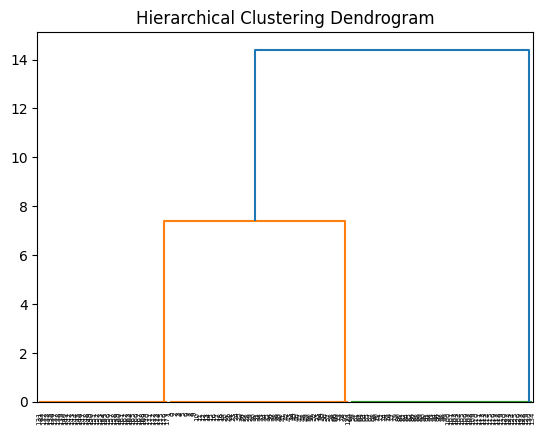

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(df[['Cluster_Hierarchical']], method='ward')
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()
